# ML pipeline for UNO

In [1]:
import os
from tqdm import tqdm
#from sklearn.metrics import accuracy_score, f1_score

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from IPython.display import clear_output
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision.io import decode_image
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader

First let us define some useful global variables :
- File paths to the data
- Translations from text to vector representation
- ML hyperparameters

In [2]:
# Filenames to access data
img_dir = "iapr-26-uno-vision-challenge/train_images"
annotations_file = "iapr-26-uno-vision-challenge/train.csv"

# List of cards : digits (0 to 9) with color, specials (draw_2, reverse, skip) with color, other special (draw_4, wild)
card_name_list = [str(color) + '_' + str(digit) for digit in range(10) for color in ['r', 'g', 'b', 'y']]
card_name_list += [str(color) + '_' + str(special) for special in ['draw_2', 'reverse', 'skip'] for color in ['r', 'g', 'b', 'y']]
card_name_list += ['draw_4', 'wild']
# Mapping from card name to its index in vector form
card_name_to_index = {card_name : index for index, card_name in enumerate(card_name_list)}

# General ML parameters :
torch.manual_seed(0)
train_val_test_split = [0.7, 0.15, 0.15]
learning_rate = 0.001
weight_decay = 0.01
batch_size = 16
nb_epochs = 10

RGB_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
RGB_normalization_std = torch.tensor([0.229, 0.224, 0.225])
transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=RGB_normalization_mean, std=RGB_normalization_std),
])

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

Using device cpu


Then let us define helper functions to handle transformations between data and ML model.

In [4]:
def divide_image(image, index):
    # Crop the image into 5 cropped images of the same size (given as tensor): 
    # 'center_card', 'player_1_cards', 'player_2_cards', 'player_3_cards', 'player_4_cards'
    colors, height, width = image.shape
    height_half_d = height // 6
    width_half_d = (width - 4*height_half_d) // 2
    centers = [[height // 2, width // 2], 
               [height - height_half_d, width // 2], 
               [height // 2, width - height_half_d], 
               [height_half_d, width // 2], 
               [height // 2, height_half_d]]
    if (index == 2) or (index == 4):
        height_half_d = width_half_d
        width_half_d = height // 6
    cropped_image = image[:, centers[index][0]-height_half_d:centers[index][0]+height_half_d, centers[index][1]-width_half_d:centers[index][1]+width_half_d]
    cropped_image = cropped_image.clone()
    if (index == 2) or (index == 4):
        cropped_image = cropped_image.transpose(-1, -2)
    return cropped_image

def label_string_to_tensor(label):
    # Give the model representation from the label annotation :
    output = torch.zeros(len(card_name_list))
    for card_name in label.split(";"):
        if (card_name != 'EMPTY'):
            output[card_name_to_index[card_name]] += 1
    return output

def label_tensor_to_string(vector):
    # Give the label annotation from the model representation :
    card_list = []
    for index, value in enumerate(list(vector.flatten())):
        nb_cards = round(value.item())
        while (nb_cards > 0):
            card_list.append(card_name_list[index])
            nb_cards -= 1
    output = output = ';'.join(card_list)
    if (len(card_list) == 0):
        output = 'EMPTY'
    return output

def image_revese_RGB_normalization(img):
    return img * RGB_normalization_std.reshape((3,1,1)).to(img.device) + RGB_normalization_mean.reshape((3,1,1)).to(img.device)

def display_tensor_images(imgs, RGB_normalized=False, shape=None, figsize=(5,5)):
    # Shape is a tuple of (nb_image_horizontal, nb_image_vertical) such that len(imgs) = nb_image_vertical*nb_image_horizontal
    # Otherwise the images are displayed in a list (horizontally)
    if (not isinstance(imgs, list)):
        imgs = [imgs]
    if (shape == None):
        shape = (1, len(imgs))
    shape_x, shape_y = shape
    fig, ax = plt.subplots(nrows=shape_y, ncols=shape_x, squeeze=False)
    fig.set_size_inches(figsize[0], figsize[1])
    for i, img in enumerate(imgs):
        img = img.clone()
        if (RGB_normalized):
            img = image_revese_RGB_normalization(img)
            img = (img*255).to(torch.uint8)
        img = v2.functional.to_pil_image(img)
        img_x = i % shape_x
        img_y = i // shape_x
        ax[img_y, img_x].imshow(np.asarray(img))
        ax[img_y, img_x].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    plt.show()

Image shape torch.Size([3, 2662, 4000])
Divided image shape torch.Size([3, 886, 2228])


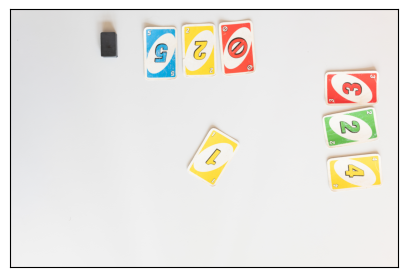

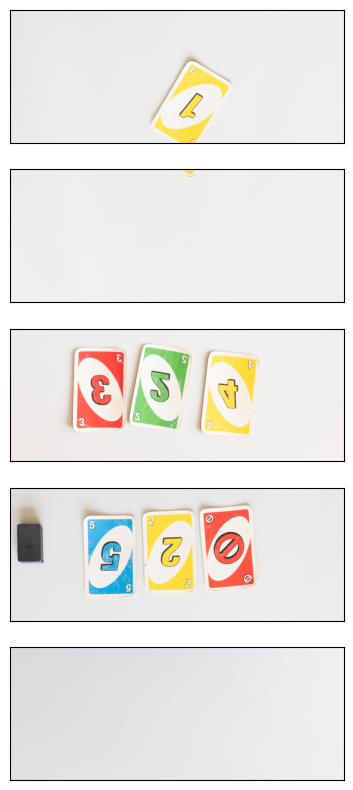

In [5]:
# Take a look a the image in the dataset
full_image_example = decode_image(os.path.join('iapr-26-uno-vision-challenge/train_images/L1000770.jpg'))
print(f"Image shape {full_image_example.shape}")
divided_images_example = [divide_image(full_image_example, i) for i in range(5)]
print(f"Divided image shape {divided_images_example[0].shape}")

display_tensor_images(full_image_example)
display_tensor_images(divided_images_example, RGB_normalized=False, shape=(1, len(divided_images_example)), figsize=(5,10))

In [6]:
class UNOImageDataset(Dataset):
    def __init__(self, img_dir, annotations_file, divide_image, label_string_to_tensor, transform=None, device='cpu'):
        # Annotations contains : 'image_id', 'center_card', 'active_player', 'player_1_cards', 'player_2_cards', 'player_3_cards', 'player_4_cards'
        annotations = pd.read_csv(annotations_file)
        self.device = device
        self.transform = transform
        # Store image labels
        self.img_labels = torch.zeros((5*len(annotations['image_id']), len(card_name_list)), dtype=torch.float32)
        self.img_labels[0::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['center_card']])
        self.img_labels[1::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_1_cards']])
        self.img_labels[2::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_2_cards']])
        self.img_labels[3::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_3_cards']])
        self.img_labels[4::5] = torch.tensor([list(label_string_to_tensor(label)) for label in annotations['player_4_cards']])
        # Store images
        self.imgs = torch.zeros((5*len(annotations['image_id']), 3, 886, 2228), dtype=torch.uint8)
        for img_index in range(len(annotations['image_id'])):
            img_path = os.path.join(img_dir, annotations['image_id'][img_index]) + '.jpg'
            full_image = decode_image(img_path)
            for divided_img_index in range(5):
                self.imgs[img_index*5 + divided_img_index] = divide_image(full_image, divided_img_index)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        image = self.imgs[idx]
        if (self.transform != None):
            image = self.transform(image)
        image = image.to(self.device)
        label = self.img_labels[idx].to(self.device)
        return image, label

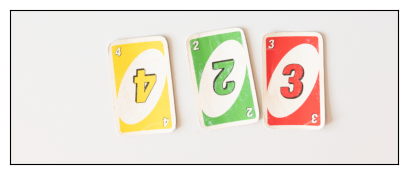

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
g_2;r_3;y_4


In [7]:
full_dataset = UNOImageDataset(img_dir, annotations_file, divide_image, label_string_to_tensor, transform=transforms, device=device)
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, train_val_test_split, generator=torch.Generator().manual_seed(42))

# Display sample
image_sample, label_sample = full_dataset.__getitem__(2)
with torch.no_grad():
    display_tensor_images(image_sample, RGB_normalized=True)
    print(label_sample)
    print(label_tensor_to_string(label_sample))

In [8]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, generator=torch.Generator().manual_seed(42))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, generator=torch.Generator().manual_seed(42))

## Define the model

In [9]:
class UNO_Model(nn.Module):
    def __init__(self):
        super().__init__()
        # Recall shape 3, 886, 2228
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(6), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(in_channels=6, out_channels=6, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(6), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(16), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(16), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2), 
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1, padding=0), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2, 2), 
        )
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Sequential(
            nn.Linear(32 * 2 * 13, 256), 
            #nn.BatchNorm1d(256), 
            nn.ReLU(inplace=True), 
            nn.Linear(256, 128), 
            #nn.BatchNorm1d(128), 
            nn.ReLU(inplace=True), 
            nn.Linear(128, 54), 
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.dropout(x)
        x = self.classifier(x)
        return x

model = UNO_Model().to(device)
print(model)
print(f"Number of parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

UNO_Model(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(6, 6, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (13): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15):

In [10]:
with torch.no_grad():
    print(model(image_sample.unsqueeze(0)))
    print(label_sample)

tensor([[ 0.1123, -0.0804,  0.0102, -0.0515,  0.2743,  0.2636, -0.0320, -0.2433,
          0.0210, -0.1848,  0.1036,  0.1437, -0.0617, -0.2467, -0.0182, -0.0924,
          0.0216,  0.2706,  0.0791,  0.0476,  0.0572, -0.0858,  0.1907,  0.0863,
         -0.2125, -0.0432,  0.0714,  0.2847,  0.1703, -0.0485, -0.0956, -0.1675,
          0.1855, -0.1395, -0.0979,  0.2250,  0.3058,  0.0145, -0.0600,  0.0433,
          0.0925,  0.1284, -0.2999, -0.1415, -0.0806, -0.4058,  0.1196, -0.3154,
         -0.0044,  0.1812, -0.0115,  0.1860, -0.0561,  0.2279]])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


## Train the model

In [11]:
def plot_training(best_epoch, val_f1s, val_losses, train_losses, first_epoch_plot=1):
    # Create plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    epochs = np.arange(1, len(val_f1s)+1)
    epoch_ticks_spacing = max(1, len(val_f1s) // 10)
    # Modify for plot
    epochs_plot = epochs[first_epoch_plot-1:]
    val_f1s_plot = val_f1s[first_epoch_plot-1:]
    val_losses_plot = val_losses[first_epoch_plot-1:]
    train_losses_plot = train_losses[first_epoch_plot-1:]
    # Plot F1 score
    ax[0].plot(epochs_plot, val_f1s_plot, label="Val")
    ax[0].vlines(best_epoch, ymin=np.min(val_f1s_plot), ymax=np.max(val_f1s_plot), color='k', ls='--', label="Best epoch")
    ax[0].set_xlabel("Training steps")
    ax[0].set_ylabel("F1-score")
    ax[0].set_title("F1-score")
    ax[0].xaxis.set_major_locator(MultipleLocator(epoch_ticks_spacing))
    ax[0].grid()
    ax[0].legend()
    # Plot losses
    ax[1].plot(epochs_plot, val_losses_plot, label="Val")
    ax[1].plot(epochs_plot, train_losses_plot, label="Train")
    ax[1].vlines(best_epoch, ymin=np.min(train_losses_plot), ymax=np.max(val_losses_plot), color='k', ls='--', label="Best epoch")
    ax[1].set_xlabel("Training steps")
    ax[1].set_ylabel("Loss")
    ax[1].set_title("Losses")
    ax[1].xaxis.set_major_locator(MultipleLocator(epoch_ticks_spacing))
    ax[1].grid()
    ax[1].legend()
    plt.tight_layout()
    plt.show()

def prediction_from_output(preds):
    return preds.clamp(0, 4).round()

def f1_score(labels, preds):
    zero = torch.zeros_like(preds)
    TP = torch.sum(torch.maximum(zero, torch.minimum(labels, preds)))
    FP = torch.sum(torch.maximum(zero, preds-labels))
    FN = torch.sum(torch.maximum(zero, labels-preds))
    return 2*TP / (2*TP + FP + FN)

def train_epoch(model, train_loader, optimizer, loss_fn):
    running_loss = 0.0
    model.train()
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        preds = model(inputs)
        loss = loss_fn(preds, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        del loss
        del preds
    return running_loss / len(train_loader)
    
def valid_epoch(model, test_loader, loss_fn):
    model.eval()
    running_loss = 0.0
    running_f1_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            preds = model(inputs)
            loss = loss_fn(preds, labels)
            running_loss += loss.item()
            running_f1_loss += f1_score(labels, preds).item()
            del loss
            del preds
        f1 = running_f1_loss / len(test_loader)
        loss = running_loss / len(test_loader)
    return f1, loss

def train(model, train_loader, val_loader, nb_epochs, optimizer, scheduler, loss_fn, show_plot=False):
    # Initialize variable to return
    best_model = model.state_dict()
    best_epoch = 0
    best_f1 = 0.0
    train_losses = []
    val_losses = []
    val_f1s = []
    for epoch in tqdm(range(nb_epochs)):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        val_f1, val_loss = valid_epoch(model, val_loader, loss_fn)
        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(val_f1)
        if (val_f1 > best_f1):
            best_model = model.state_dict()
            best_epoch = epoch + 1
            best_f1 = val_f1
        if show_plot:
            clear_output()
            plot_training(best_epoch, val_f1s, val_losses, train_losses, first_epoch_plot=1)
            print(f"Current train loss = {train_losses[-1]}, current validation loss = {val_losses[-1]}, current validation f1 loss = {val_f1s[-1]}")
    return best_model, best_f1, best_epoch, val_f1s, val_losses, train_losses

In [12]:
def loss_fn(preds, labels):
    return nn.functional.mse_loss(preds, labels) + nn.functional.cross_entropy(preds, labels)
#loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, nb_epochs)

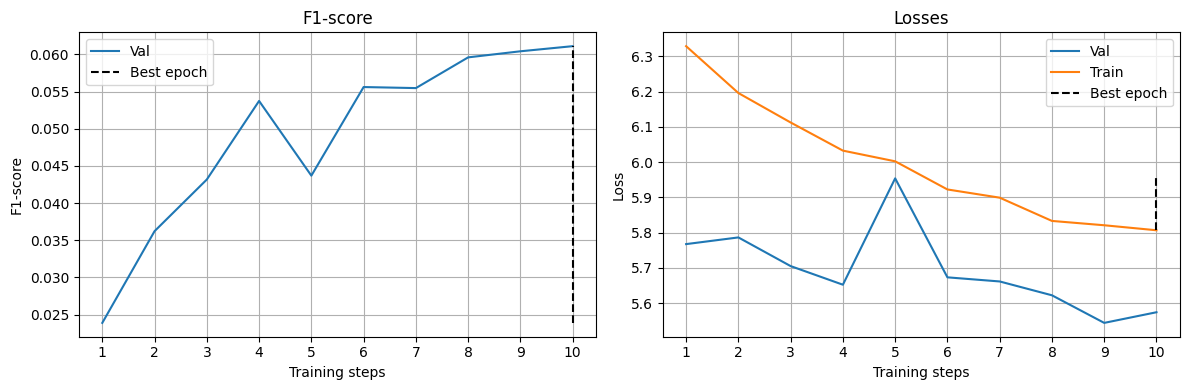

100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [16:46<00:00, 100.66s/it]

Current train loss = 5.806687222586738, current validation loss = 5.5741366147994995, current validation f1 loss = 0.0611052056774497
Best model at epoch 10 -> 6.11% F1 score


In [13]:
train_output = train(model, train_loader, val_loader, nb_epochs, optimizer, scheduler, loss_fn, show_plot=True)
best_model, best_f1, best_epoch, val_f1s, val_losses, train_losses = train_output
print(f"Best model at epoch {best_epoch} -> {100*best_f1:.2f}% F1 score")

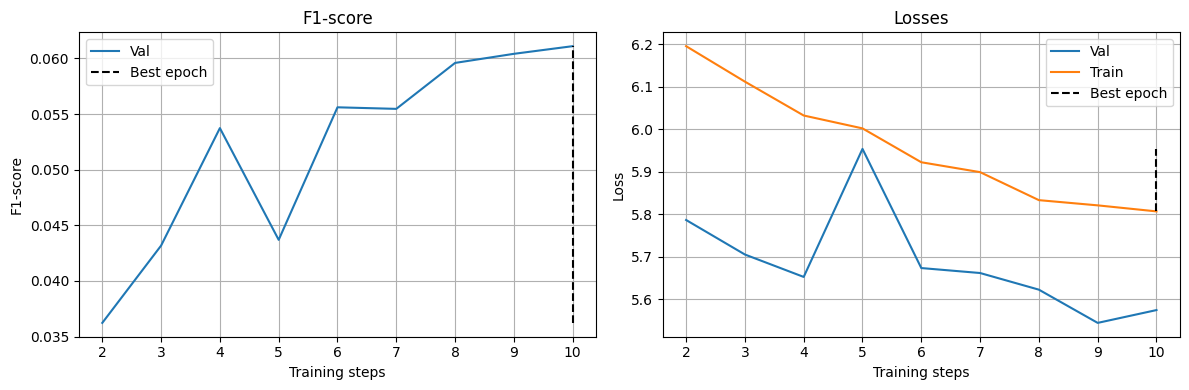

In [14]:
plot_training(best_epoch, val_f1s, val_losses, train_losses, first_epoch_plot=2)

In [16]:
with torch.no_grad():
    model = UNO_Model().to(device)
    model.load_state_dict(best_model)
    model.eval()
    label_predict = model(image_sample.unsqueeze(0))
    print(label_predict)
    print(label_tensor_to_string(label_predict))
    print(label_sample)
    print(label_tensor_to_string(label_sample))

tensor([[-0.3541, -0.3423, -0.0911, -0.1736, -0.3750, -0.0915,  0.6275, -0.6024,
         -0.2962,  0.4259, -0.2414, -0.2729,  0.3329, -0.0557,  0.0255, -0.0595,
          0.2950,  0.3671,  0.1893, -0.0827, -0.0385,  0.1175,  0.2812, -0.4759,
          0.0853, -0.0729, -0.2092, -0.1290,  0.0142,  0.4343,  0.3906,  0.3539,
          0.2344, -0.2466, -0.2880,  0.1401,  0.3186, -0.5919, -0.3090, -0.2167,
         -0.1055, -0.0765,  0.7191, -0.3948, -0.2694, -0.2567, -0.1256, -0.0795,
         -0.3406, -0.0011, -0.0489, -0.1724,  0.1656,  0.4596]])
b_1;b_draw_2
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
g_2;r_3;y_4
